# RevRate - Selekcja cech, Preprocessing, Trening

## Importy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, explained_variance_score, median_absolute_error

## Wczytanie danych po inzynierii cech

In [2]:
df_features = pd.read_csv('../data/features_data.csv')
print('Ksztalt danych:', df_features.shape)
df_features.head()

Ksztalt danych: (184876, 17)


,Price,Condition,Vehicle_brand,Vehicle_model,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,Drive,Transmission,Type,Doors_number,Colour,car_age,mileage_per_year,power_to_displacement,age_x_mileage
0,86200.0,New,Abarth,595,1.0,145.0,1400.0,Gasoline,Front wheels,Manual,small_cars,3.0,gray,0.0,1.000000,0.103571,0.0
1,44900.0,Used,Abarth,500,52000.0,180.0,1368.0,Gasoline,Front wheels,Automatic,small_cars,3.0,silver,3.0,17333.333333,0.131579,156000.0
2,39900.0,Used,Abarth,500,29000.0,160.0,1368.0,Gasoline,Front wheels,Manual,small_cars,3.0,gray,14.0,2071.428571,0.116959,406000.0
3,97900.0,New,Abarth,595,600.0,165.0,1368.0,Gasoline,Front wheels,Manual,small_cars,3.0,blue,5.0,120.000000,0.120614,3000.0
4,62950.0,Used,Abarth,595,46060.0,180.0,1368.0,Gasoline,Front wheels,Manual,small_cars,3.0,gray,10.0,4606.000000,0.131579,460600.0


## Selekcja cech

Wybrano 16 cech z 16 dostepnych


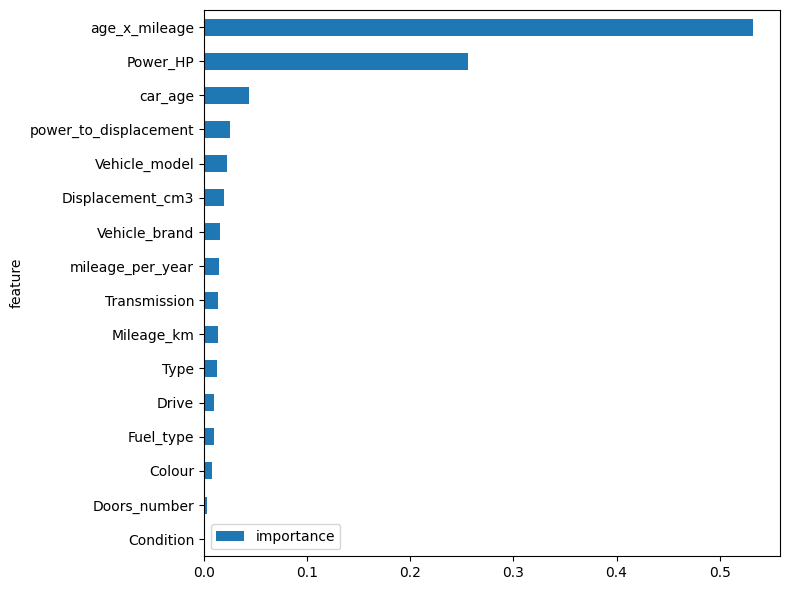

In [3]:
n_top = 20
threshold = 0.01

X_feat = df_features.drop(columns=['Price']).copy()
for col in X_feat.select_dtypes(include=['object']).columns:
    X_feat[col] = X_feat[col].astype('category').cat.codes
y_feat = df_features['Price']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_feat, y_feat)

importances = (
    pd.DataFrame({'feature': X_feat.columns, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
)

selected = importances[(importances['importance'] >= threshold) | (importances.reset_index().index < n_top)]
selected_features = selected['feature'].tolist()

print(f'Wybrano {len(selected_features)} cech z {len(X_feat.columns)} dostepnych')

importances.head(20).plot.barh(x='feature', y='importance', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Preprocessing danych

In [4]:
available_features = [f for f in selected_features if f in df_features.columns]

X = df_features[available_features].copy()
y = df_features['Price'].values

for col in X.select_dtypes(include=['object']).columns:
    converted = pd.to_numeric(X[col], errors='coerce')
    if converted.notna().all():
        X[col] = converted
    else:
        X[col] = X[col].astype('category')

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['category']).columns.tolist()

n_num = len(numeric_features)
n_cat = len(categorical_features)
print(f'Model uzywa {len(available_features)} cech (numeryczne: {n_num}, kategoryczne: {n_cat}):')

if numeric_features:
    print(f'Numeryczne ({n_num}):')
    for f in numeric_features:
        print(f'  - {f}')

if categorical_features:
    print(f'\nKategoryczne ({n_cat}):')
    for f in categorical_features:
        print(f'  - {f}')

Model uzywa 16 cech (numeryczne: 8, kategoryczne: 8):
Numeryczne (8):
  - age_x_mileage
  - Power_HP
  - car_age
  - power_to_displacement
  - Displacement_cm3
  - mileage_per_year
  - Mileage_km
  - Doors_number

Kategoryczne (8):
  - Vehicle_model
  - Vehicle_brand
  - Transmission
  - Type
  - Drive
  - Fuel_type
  - Colour
  - Condition


## Split zbioru na Train i Test

In [5]:
bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=bins
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (147900, 16) Test: (36976, 16)


## Trening modelu (XGBoost)

In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 400],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],

#     'n_estimators': [300, 500, 800],
#     'max_depth': [5, 7, 9, 11],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
#     'min_child_weight': [1, 3, 5, 10],
#     'gamma': [0, 0.1, 0.3, 1],
#     'reg_alpha': [0, 0.01, 0.1, 1],
#     'reg_lambda': [1, 3, 5],
}

base_xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror',
    enable_categorical=True,
    # device='cuda',
    verbosity=0,
    tree_method='hist',
)

grid_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=60,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=2,
    random_state=42,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print('Najlepsze parametry:', grid_search.best_params_)
print('Najlepszy CV score (negRMSE):', grid_search.best_score_)

e:\Repo\ASI_SAVEME\2526L_win_ASI_17_Przewidywanie-cen-samochodow\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=60. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=400, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=400, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=400, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.7s
[CV] END co

## Ewaluacja modelu

In [7]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'Train  RMSE={train_rmse:.2f}  MAE={train_mae:.2f}  R2={train_r2:.4f}')
print(f'Test   RMSE={test_rmse:.2f}  MAE={test_mae:.2f}  R2={test_r2:.4f}')

Train  RMSE=6883.62  MAE=4536.59  R2=0.9632
Test   RMSE=10421.57  MAE=6230.21  R2=0.9156


## Zapis modelu, preprocessora i listy cech

In [8]:
joblib.dump(best_model, '../models/custom_model.pkl')
                         
print('Model zapisany do models/custom_model.pkl')

Model zapisany do models/custom_model.pkl
